# 3. Desarrollo
## 3.1 Algoritmo: Laberinto Recursivo
1. Iniciar en una posición dada de la matriz, indicada por la fila y la columna.

2. Verificar si la posición actual está fuera de los límites de la matriz.
   - Si está fuera, regresar `False`.

3. Verificar si la posición actual es una pared o una casilla ya visitada.
   - Si la casilla contiene `1` o `X`, regresar `False`.

4. Verificar si la posición actual es la salida `F`.
   - Si es la salida, regresar `True`.

5. Marcar la posición actual como visitada usando `X`, siempre que no sea la posición inicial `S`.

6. Intentar avanzar recursivamente en las cuatro direcciones posibles:
   - Arriba
   - Abajo
   - Izquierda
   - Derecha

7. Si alguna de las llamadas recursivas encuentra el camino hacia la salida:
   - Marcar la posición actual como parte del camino correcto usando `*`.
   - Regresar `True`.

8. Si ninguna dirección lleva a la salida:
   - Regresar `False`.

9. Al finalizar, si la función regresa `True`, significa que existe un camino desde el inicio hasta la salida.
   Si regresa `False`, significa que no existe un camino válido.


## 3.2 Descripción de funciones
### Función `buscar_camino(matriz_lab, fila, columna)`

Esta función busca recursivamente un camino desde la posición actual hasta la salida del laberinto utilizando la técnica de backtracking.

#### Parámetros
- `matriz_lab`: matriz que representa el laberinto.
- `fila`: posición actual de la fila.
- `columna`: posición actual de la columna.

#### Funcionamiento
1. Verifica si la posición actual está fuera de los límites de la matriz.
   - Si está fuera, regresa `False`.

2. Verifica si la posición actual es una pared (`1`) o una casilla ya visitada (`*`).
   - Si se cumple alguna condición, regresa `False`.

3. Verifica si la posición actual corresponde a la salida (`F`).
   - Si se encuentra la salida, regresa `True`.

4. Marca la posición actual con `*` para evitar volver a recorrerla.

5. Imprime el estado actual de la matriz.

6. Realiza llamadas recursivas para intentar avanzar en las cuatro direcciones:
   - Arriba
   - Abajo
   - Izquierda
   - Derecha

7. Si alguna llamada recursiva encuentra la salida:
   - Regresa `True`.

8. Si ninguna dirección funciona:
   - Se aplica backtracking.
   - La casilla actual se restaura a `0`.
   - Se imprime el retroceso realizado.

9. Finalmente, regresa `False` indicando que desde esa posición no existe un camino válido.

## 3.3 Análisis de complejidad
- Tiempo: O(n²) en el peor caso.
- Espacio: O(n²) debido a la pila de llamadas recursivas.



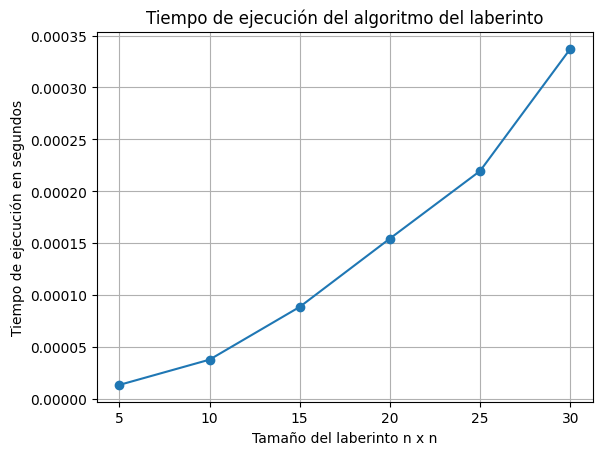

In [1]:
import time
import matplotlib.pyplot as plt

def buscar_camino_sin_imprimir(matriz_lab, fila, columna):
    n = len(matriz_lab)

    if fila < 0 or fila >= n or columna < 0 or columna >= n:
        return False

    if matriz_lab[fila][columna] == 1 or matriz_lab[fila][columna] == '*':
        return False

    if matriz_lab[fila][columna] == 'F':
        return True

    if matriz_lab[fila][columna] != 'S':
        matriz_lab[fila][columna] = '*'

    if buscar_camino_sin_imprimir(matriz_lab, fila - 1, columna):
        return True

    if buscar_camino_sin_imprimir(matriz_lab, fila + 1, columna):
        return True

    if buscar_camino_sin_imprimir(matriz_lab, fila, columna - 1):
        return True

    if buscar_camino_sin_imprimir(matriz_lab, fila, columna + 1):
        return True

    if matriz_lab[fila][columna] != 'S':
        matriz_lab[fila][columna] = 0

    return False


tamaños = []
tiempos = []

for n in range(5, 31, 5):
    matriz = [[0 for columna in range(n)] for fila in range(n)]

    matriz[0][0] = 'S'
    matriz[n - 1][n - 1] = 'F'

    inicio = time.time()
    buscar_camino_sin_imprimir(matriz, 0, 0)
    fin = time.time()

    tamaños.append(n)
    tiempos.append(fin - inicio)

plt.plot(tamaños, tiempos, marker='o')
plt.xlabel("Tamaño del laberinto n x n")
plt.ylabel("Tiempo de ejecución en segundos")
plt.title("Tiempo de ejecución del algoritmo del laberinto")
plt.grid(True)
plt.show()

### Interpretación de resultados

Para obtener la gráfica de tiempo de ejecución, se realizaron pruebas con laberintos cuadrados de diferentes tamaños. 
En cada prueba se midió el tiempo que tarda la función recursiva en encontrar la salida. 

## 3.4 Función recursiva

## 3.5 Pruebas

| Prueba | Descripción de la prueba | Posición inicial | Resultado esperado | Resultado obtenido |
|---|---|---|---|---|
| 1 | Laberinto con camino válido desde `S` hasta `F` | (2,1) | Se encontró la salida | Se encontró la salida |
| 2 | Laberinto con camino bloqueado por paredes | (2,1) | No se encontró salida | No se encontró salida |
| 3 | Inicio rodeado completamente por paredes | (2,1) | No se encontró salida | No se encontró salida |
| 4 | Salida accesible de forma directa | (2,1) | Se encontró la salida | Se encontró la salida |
| 5 | Laberinto con múltiples rutas posibles | (2,1) | Se encontró la salida | Se encontró la salida |

---

### Prueba 1

```python
matriz_lab = [
    [1,1,0,0,0],
    [1,1,0,1,1],
    [1,'S',0,0,0],
    [1,1,0,1,1],
    [1,1,0,0,'F']
]


### Prueba 2

```python
matriz_lab = [
    [1,1,0,0,0],
    [1,1,1,1,1],
    [1,'S',0,0,0],
    [1,1,1,1,1],
    [1,1,0,0,'F']
]

### Prueba 3

```python
matriz_lab = [
    [1,1,1,1,1],
    [1,1,1,1,1],
    [1,'S',1,1,1],
    [1,1,1,1,1],
    [1,1,0,0,'F']
]

### Prueba 4

```python
matriz_lab = [
    [1,1,1,1,1],
    [1,1,1,1,1],
    [1,'S',0,0,'F'],
    [1,1,1,1,1],
    [1,1,1,1,1]
]

### Prueba 5

```python
matriz_lab = [
    [1,0,0,0,1],
    [1,0,1,0,1],
    [1,'S',1,0,0],
    [1,0,0,0,1],
    [1,1,1,0,'F']
]